**1.  Suppose an exam is to be given to students at a local college. To test its validity, the exam is administered to a sample of 10 students, and the scores are: 65, 70, 68, 73, 75, 80, 85, 78, 90, 100. We will estimate the 95% confidence interval for the mean of the population (i.e., the expected mean for a large number of students) using two different methods:**

(a) Calculate the sample mean and standard deviation of this set. Then use the formula to calculate the confidence interval.

In [171]:
import numpy as np

# Data
data = np.array([65, 70, 68, 73, 75, 80, 85, 78, 90, 100])

# Mean and standard deviation
mean = np.mean(data)
sd = np.std(data)
print(f'Mean: {mean}\nStandard Deviation: {sd:.2f}')

# 95% confidence interval (t = 2.262, n = 10)
t= 2.262
n = 10
r = ((t)*(sd/(n**0.5)))

# Bounds
low_conf_int = (mean - r)
hi_conf_int = (mean + r)
print(f'95% Confidence Interval: [{low_conf_int:.2f}, {hi_conf_int:.2f}]')


Mean: 78.4
Standard Deviation: 10.23
95% Confidence Interval: [71.08, 85.72]


**(b) Construct 40 bootstrapped samples of the data. Calculate the mean of each sample, and use this set of means to estimate the 95% confidence interval for the mean of the population**

In [172]:

bootstrapped_stats = []

for i in range(40):
    # Randomly sample from data (with replacement)
    sample = np.random.choice(data, size=len(data), replace=True)

    mean = np.mean(sample)
    bootstrapped_stats.append(mean)

bootstrapped_stats = np.array(bootstrapped_stats)

# Compute 95% confidence interval bounds (2.5th and 97.5th percentiles)
lower_percentile = (100 - 95) / 2
upper_percentile = 100 - lower_percentile
ci_lower = np.percentile(bootstrapped_stats, lower_percentile)
ci_upper = np.percentile(bootstrapped_stats, upper_percentile)

print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

95% Confidence Interval: [72.97, 83.66]


**(c) Which method would you choose to estimate the confidence interval for this use case. Explain why you believe your chosen method is more reliable?**

This sample is small, so I would use the bootstrapping method. Since we don't know if the exam scores follow a normal distribution, resampling the data using bootstrapping will create a better distribution of the mean, giving a more reliable confidence interval.

**2. Using the same 10 exam scores as in question 1, we will use cross-validation to estimate the prediction error of an exam score on new (holdout) data.**

**(a) Randomly assign each score into one of 5 subsets, each containing only two scores.**

In [173]:
import random

random.shuffle(data)

# Split into 5 subsets of 2 scores each
subsets = [data[i:i+2] for i in range(0, len(data), 2)]

# Print the subsets
for idx, subset in enumerate(subsets, start=1):
    print(f"Subset {idx}: {subset}")

Subset 1: [85 73]
Subset 2: [100  90]
Subset 3: [68 80]
Subset 4: [75 78]
Subset 5: [65 70]


**(b) For each of the five subsets created, we have 8 associated “training” scores and 2 “validation” scores. For each of the 5 training sets, calculate the average score.**

In [174]:
training_means = []

# Calculate training set mean for each validation subset
for idx, val_set in enumerate(subsets, start=1):
    # Training set = all data not in the current validation subset
    training_set = np.setdiff1d(data, val_set)
    
    # Compute mean of the training set
    mean_train = np.mean(training_set)
    training_means.append(mean_train)
    
    print(f"Mean of Training Set {idx}: {mean_train:.2f}")

Mean of Training Set 1: 78.25
Mean of Training Set 2: 74.25
Mean of Training Set 3: 79.50
Mean of Training Set 4: 78.88
Mean of Training Set 5: 81.12


**(c) If we treat each of the 5 calculated average scores as a prediction, what is the mean absolute error computed on each associated validation set (each containing the 2 remaining elements)?**

In [175]:
mae_values = []
for val_set, train_mean in zip(subsets, training_means):
 # Compute average abs. diff between validation data and training mean
    mae = np.mean(np.abs(val_set - train_mean))
    
    mae_values.append(mae)
    
    print(f"Subset: {val_set}, MAE: {mae:.2f}")

Subset: [85 73], MAE: 6.00
Subset: [100  90], MAE: 20.75
Subset: [68 80], MAE: 6.00
Subset: [75 78], MAE: 2.38
Subset: [65 70], MAE: 13.62


**(d) Compute the average mean absolute error across the 5 cross-validation folds**

In [176]:
avg_mae = np.mean(mae_values)
print(f"Average MAE: {avg_mae:.2f}")

Average MAE: 9.75


**(e) Suppose we conduct this exam again, and for simplicity let’s assume we get exactly the same scores. If we had used the average exam score to predict the “new” exam scores, what would the mean absolute error be on this “new” set?**

In [177]:
score_difs = []

for i in data:
    # Absolute difference between each score and the mean
    dif = abs(i - mean)
    score_difs.append(dif)

# Convert to array and sum differences
tot = np.array(score_difs).sum()

# Divide by number of observations to get MAE
new_mae = tot/10

print(f"Mean Absolute Error on 'new' exam: {new_mae:.2f}")

Mean Absolute Error on 'new' exam: 9.92


**3. This problem involves the OJ data, which is part of the ISLP package. We will use classification trees to predict the value of Purchase.**

In [207]:
import pandas as pd
from ISLP import load_data
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)

#load dataset
OJ = load_data('OJ')


**(a) Create a training set contain a random sample of 800 observations, and a test set containing the remaining observations. You will also need to convert the Store7 column to numeric.**

In [ ]:
OJ['Store7'] = OJ['Store7'].map({'Yes': 1, 'No': 0})


train, test = train_test_split(OJ, train_size=800, random_state=42)

#Convert Store7 to numeric (in case it’s read as string or object)
OJ['Store7'] = pd.to_numeric(OJ['Store7'], errors='coerce')

print(OJ['Store7'].unique())

#print(OJ['Store7'].head(10))

[0 1]


**(b) Fit a single tree to the training data, with Purchase as the response and the other variables as predictors. Use 6 as the maximum number of leaf nodes. Produce a confusion matrix and state the total misclassification error on training data.**

In [180]:
# Split data into features (X) and target (y) for training and testing
y_train = train['Purchase']
X_train = train.drop('Purchase', axis=1)
y_test = test['Purchase']
X_test = test.drop('Purchase', axis=1)

# Initialize Decision Tree Classifier with up to 6 leaf nodes
tree1 = DTC(max_leaf_nodes=6, random_state=2)

# Fit the model on training data
tree1.fit(X_train, y_train)

# Predict on training set
pred_train = tree1.predict(X_train)

# Compute confusion matrix and training error
conf_train = confusion_matrix(y_train, pred_train)
train_error = 1 - accuracy_score(y_train, pred_train)

print("Training confusion matrix")
print(conf_train)
print(f'Training error: {train_error:.4f}')

Training confusion matrix
[[451  43]
 [ 82 224]]
Training error: 0.1562


**(c) Create a plot of the tree and interpret the results.**

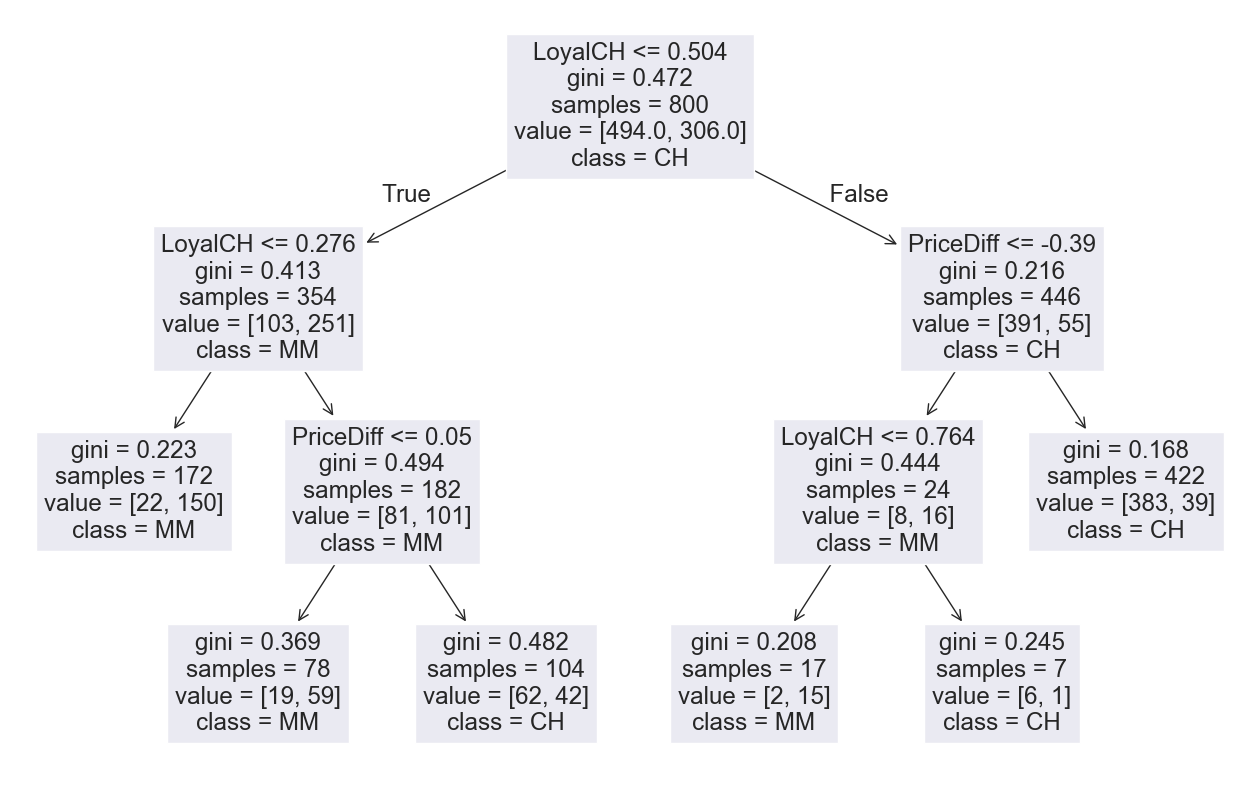

In [181]:
plt.figure(figsize=(16,10))
plot_tree(tree1, feature_names=X_train.columns, class_names=['CH', 'MM'])
plt.show()

- The model shows that customer loyalty to CH is the strongest predictor of purchase type.
- Low loyalty values generally indicate MM purchases, while high loyalty values indicate CH purchases.
- Price differences further refine predictions — when CH is much cheaper, CH purchases dominate.
- Overall, the decision tree reveals that loyalty and relative pricing are key drivers of customer choice.

**(d) Predict the response on the test data, and produce a confusion matrix. State the total misclassification error on test data.**

In [182]:
# Predict on test set
pred_test = tree1.predict(X_test)

# Compute confusion matrix and test error
conf_test = confusion_matrix(y_test, pred_test)
test_error = 1 - accuracy_score(y_test, pred_test)

print("Testing confusion matrix")
print(conf_test)
print(f'Testing error: {test_error:.4f}')

Testing confusion matrix
[[149  10]
 [ 42  69]]
Testing error: 0.1926


**(e) Fit a new tree to the data, this time using 8 for the maximum number of leaf nodes. How does the test error change?**

In [183]:
tree2 = DTC(max_leaf_nodes=8, random_state=2)
tree2.fit(X_train, y_train)

# Predict on test data
pred_test2 = tree2.predict(X_test)

# Calculate testing error
test_error2 = 1 - accuracy_score(y_test, pred_test2)

print(f'Testing error: {test_error2:.4f}')

Testing error: 0.2148


When the tree size was increased from 6 to 8 leaf nodes, the test error rose from 0.1926 to 0.2148.

**(f) Is this new model in part (e) overfit? Why or why not?**

Yes, since the test error increased, this indicates that adding complexity led to slightly worse performance on the test data, suggesting the larger tree began to overfit the training data.

**(g) Use cross-validation to determine the optimal number of leaf nodes. When you train a model using this number of leaf nodes, does the total misclassification error on test decrease?**

In [184]:
from sklearn.model_selection import cross_validate

# Range of possible leaf node counts to test
leaf_sizes = range(2,21)

cv_scores = []

# Perform cross-validation for each leaf size
for size in leaf_sizes:
    model = DTC(max_leaf_nodes=size, random_state=2)
    scores = cross_validate(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = np.mean(scores['test_score'])
    cv_scores.append(mean_score)
    print(f"max_leaf_nodes={size}: mean CV accuracy = {mean_score:.5f}")

# Find the best number of leaf nodes
best_size = leaf_sizes[np.argmax(cv_scores)]
print(f"\nBest number of leaf nodes: {best_size}")

# Train final model with this optimal size
final_model = DTC(max_leaf_nodes=best_size, random_state=42)
final_model.fit(X_train, y_train)

# Evaluate on test data
y_pred = final_model.predict(X_test)
test_error = 1 - accuracy_score(y_test, y_pred)

print(f"Test misclassification error (best model): {test_error:.4f}")

max_leaf_nodes=2: mean CV accuracy = 0.79625
max_leaf_nodes=3: mean CV accuracy = 0.79625
max_leaf_nodes=4: mean CV accuracy = 0.81125
max_leaf_nodes=5: mean CV accuracy = 0.82625
max_leaf_nodes=6: mean CV accuracy = 0.83000
max_leaf_nodes=7: mean CV accuracy = 0.83125
max_leaf_nodes=8: mean CV accuracy = 0.83500
max_leaf_nodes=9: mean CV accuracy = 0.83500
max_leaf_nodes=10: mean CV accuracy = 0.83125
max_leaf_nodes=11: mean CV accuracy = 0.83000
max_leaf_nodes=12: mean CV accuracy = 0.83000
max_leaf_nodes=13: mean CV accuracy = 0.83500
max_leaf_nodes=14: mean CV accuracy = 0.83250
max_leaf_nodes=15: mean CV accuracy = 0.83250
max_leaf_nodes=16: mean CV accuracy = 0.83250
max_leaf_nodes=17: mean CV accuracy = 0.82750
max_leaf_nodes=18: mean CV accuracy = 0.82750
max_leaf_nodes=19: mean CV accuracy = 0.82875
max_leaf_nodes=20: mean CV accuracy = 0.83125

Best number of leaf nodes: 13
Test misclassification error (best model): 0.2444


The test misclassification was previously 0.2148 when we used 8 nodes and with 13 it is 0.2444, so it did not decrease.

**(h) Create a random forest model to predict Purchase. What are your initial hyperparameters? What is the total misclassification rate on the test set?**

In [185]:
from sklearn.ensemble import RandomForestClassifier as RFC

rf_OJ = RFC(max_features='sqrt',
             n_estimators=100,
             random_state=2)

rf_OJ.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [186]:
y_pred_rf = rf_OJ.predict(X_test)
test_error_rf = 1 - accuracy_score(y_test, y_pred_rf)

print(f"Test misclassification rate: {test_error_rf:.4f}")

Test misclassification rate: 0.2296


initial hyperparameters:
- max_features='sqrt'
- n_estimators=100 
- random_state=2
- max_depth=None
- min_samples_split=2
- min_samples_leaf=1

**(i) Iterate on your random forest model to search for optimal hyperparameters. What are your chosen final hyperparameters? What is the total misclassification rate?**

In [187]:
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings("ignore") 

rf = RFC(random_state=2)

param_grid = {
    'n_estimators': [50, 100, 200],         # number of trees
    'max_depth': [None, 5, 10, 20],        # maximum depth of each tree
    'min_samples_split': [2, 5, 10],       # minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],         # minimum samples per leaf
    'max_features': ['auto', 'sqrt', 'log2']  # number of features to consider at each split
}

# Grid search
grid = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

# Best hyperparameters
print("Best hyperparameters:")
for param, value in grid.best_params_.items():
    print(f"{param}: {value}")

# Evaluate on test set
best_rf = grid.best_estimator_
y_pred_rf2 = best_rf.predict(X_test)

test_error_rf2 = 1 - accuracy_score(y_test, y_pred_rf2)

print(f"\nTest misclassification rate: {test_error_rf2:.4f}")

Best hyperparameters:
max_depth: None
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 10
n_estimators: 100

Test misclassification rate: 0.2037


**(j) Construct a lift chart for your final random forest model on test data. Use it to estimate the total segmentation of your model.**

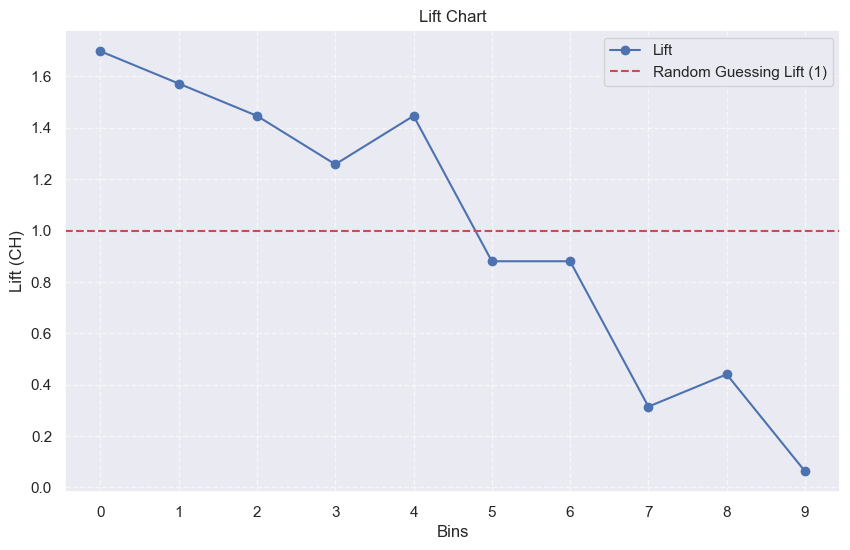

In [213]:
def plot_lift_chart(y_true, y_preds, n_bins=10):
    
    data = pd.DataFrame({'y_true': y_true, 'y_preds': y_preds})

    data = data.sort_values(by='y_preds', ascending=False)
    data['bin'] = pd.qcut(data['y_preds'], n_bins, labels=False)

        # Use top class as reference
    top_class = data['y_true'].value_counts().idxmax()

    lift_data = data.groupby('bin').agg(
        total_count=('y_true', 'count'),
        actual_top_class_count=('y_true', lambda x: (x == top_class).sum())
    ).reset_index()

    expected_rate = (data['y_true'] == top_class).mean()
    lift_data['lift'] = (lift_data['actual_top_class_count'] / lift_data['total_count']) / expected_rate
    y_label = f'Lift ({top_class})'
# Plot
    plt.figure(figsize=(10, 6))
    plt.plot(lift_data['bin'], lift_data['lift'], marker='o', label='Lift')
    plt.axhline(y=1, color='r', linestyle='--', label='Random Guessing Lift (1)')
    plt.title('Lift Chart')
    plt.xlabel('Bins')
    plt.ylabel(y_label)
    plt.xticks(lift_data['bin'])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

y_pred_proba = best_rf.predict_proba(X_test)[:, 1]  
plot_lift_chart(y_test, y_pred_proba, n_bins=10)

From the lift chart, the model performs better than random guessing in about the first five bins, where the lift values are above 1. After that, the lift drops to around or below 1, meaning the model isn’t adding much value. So, the total segmentation of the model is about five segments where it makes useful predictions.

**(k) Create a gradient boosting model to predict Purchase. What are your initial hyperparameters? What is the total misclassification rate on the test set?**

In [189]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

gbm = GBC(learning_rate=0.5,
               n_estimators=100,
               max_depth=5,
               random_state=2)
gbm.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.5
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [190]:
y_pred_gbm = gbm.predict(X_test)

test_error_gbm = 1 - accuracy_score(y_test, y_pred_gbm)

print(f"\nTest misclassification rate: {test_error_gbm:.4f}")


Test misclassification rate: 0.2333


Initial hyperparameters:
- learning_rate = 0.5
- n_estimators = 100
- max_depth = 5
- random_state = 2

**(l) Iterate on your gradient boosting model to search for optimal hyperparameters. What are your chosen final hyperparameters? What is the total misclassification rate?**

In [191]:
# Define parameter grid
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5]
}

gbm = GBC(random_state=2)

# Grid search with 5-fold CV
grid = GridSearchCV(gbm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

# Best model
best_gbm = grid.best_estimator_

# Predict on test set
y_pred_gbm2 = best_gbm.predict(X_test)

# Misclassification rate
misclass_rate = 1 - accuracy_score(y_test, y_pred_gbm2)


print("Best hyperparameters:")
for param, value in grid.best_params_.items():
    print(f"{param}: {value}")
    
print("\nMisclassification rate:", round(misclass_rate, 4))

Best hyperparameters:
learning_rate: 0.05
max_depth: 3
n_estimators: 100

Misclassification rate: 0.2074


**(m) Construct a dual lift chart which compares your best random forest model to your best gradient boosting model. Use it to explain which model better segments the data.**

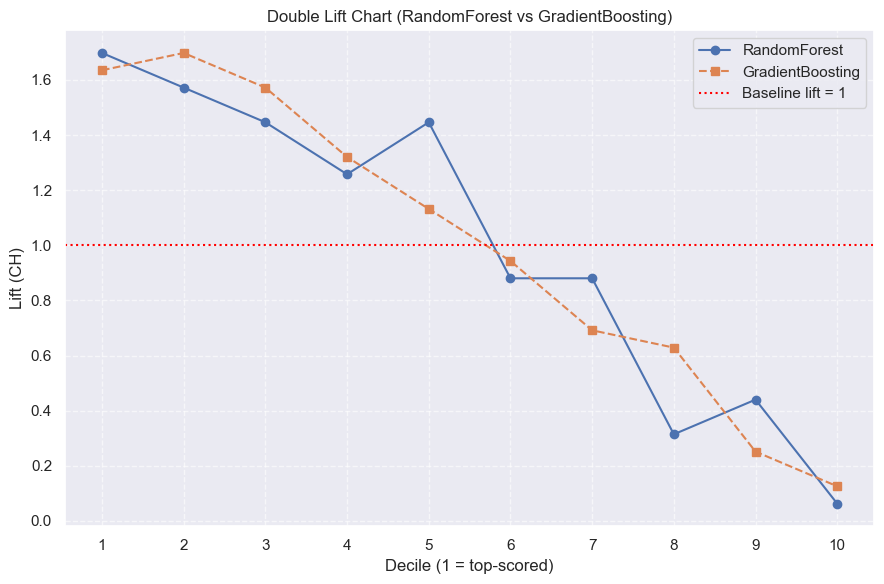

(  bin  count  positives      rate      lift
 0   1     27         27  1.000000  1.698113
 1   2     27         25  0.925926  1.572327
 2   3     27         23  0.851852  1.446541
 3   4     27         20  0.740741  1.257862
 4   5     27         23  0.851852  1.446541
 5   6     27         14  0.518519  0.880503
 6   7     27         14  0.518519  0.880503
 7   8     27          5  0.185185  0.314465
 8   9     27          7  0.259259  0.440252
 9  10     27          1  0.037037  0.062893,
   bin  count  positives      rate      lift
 0   1     27         26  0.962963  1.635220
 1   2     27         27  1.000000  1.698113
 2   3     27         25  0.925926  1.572327
 3   4     27         21  0.777778  1.320755
 4   5     27         18  0.666667  1.132075
 5   6     27         15  0.555556  0.943396
 6   7     27         11  0.407407  0.691824
 7   8     27         10  0.370370  0.628931
 8   9     27          4  0.148148  0.251572
 9  10     27          2  0.074074  0.125786)

In [212]:
# --- Double Lift Chart: simple final version ---
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _lift_by_decile(y_true, y_score, n_bins=10, pos_label=None):
    y = pd.Series(y_true)
    if pos_label is None:
       vc = y.value_counts()
       pos_label = vc.idxmin() if len(vc) == 2 else vc.index[0] 

    y_bin = (y == pos_label).astype(int)
    df = pd.DataFrame({"y": y_bin, "score": y_score})  

    # High scores first; 1 = top decile
    ranks = df["score"].rank(method="first", ascending=False)
    df["bin"] = pd.qcut(ranks, q=n_bins, labels=range(1, n_bins+1)) 

    base_rate = df["y"].mean()
    tab = (
    df.groupby("bin", observed=True)
    .agg(count=("y", "size"), positives=("y", "sum"))
    .reset_index()
    )
    tab["rate"] = tab["positives"] / tab["count"]
    tab["lift"] = tab["rate"] / base_rate
    return tab, pos_label

def plot_double_lift_chart(
 y_true, score1, score2,
 model1_name="Model A", model2_name="Model B",
 n_bins=10, pos_label=None
):
    tab1, pos = _lift_by_decile(y_true, score1, n_bins=n_bins, pos_label=pos_label)
    tab2, _ = _lift_by_decile(y_true, score2, n_bins=n_bins, pos_label=pos) 

    x = tab1["bin"].astype(int)

    plt.figure(figsize=(9,6))
    plt.plot(x, tab1["lift"].values, marker="o", label=f"{model1_name}")
    plt.plot(x, tab2["lift"].values, marker="s", linestyle="--", label=f"{model2_name}")
    plt.axhline(1.0, linestyle=":", color="red", label="Baseline lift = 1")
    plt.title(f"Double Lift Chart ({model1_name} vs {model2_name})")
    plt.xlabel("Decile (1 = top-scored)")
    plt.ylabel(f"Lift ({pos})")
    plt.xticks(range(1, n_bins+1))
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    filename = f"double_lift_{model1_name}_vs_{model2_name}.png".replace(" ", "_")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    return tab1, tab2

# ---------- Run it ----------

best_rf.fit(X_train, y_train)
best_gbm.fit(X_train, y_train)

POS = "CH"
rf_col = list(best_rf.classes_).index(POS)
gbm_col = list(best_gbm.classes_).index(POS)

rf_score = best_rf.predict_proba(X_test)[:, rf_col]
gbm_score = best_gbm.predict_proba(X_test)[:, gbm_col]

plot_double_lift_chart(
 y_test, rf_score, gbm_score,
 model1_name="RandomForest", model2_name="GradientBoosting",
 n_bins=10, pos_label=POS
)

The Random Forest model shows slightly higher lift in the top deciles, meaning it separates high-probability cases more effectively. Gradient Boosting performs more evenly but with lower peak lift. Overall, Random Forest provides better segmentation at the top of the ranking.